# Notebook 5

## Feature Engineering

Author: Morgan Lee

Purpose: The objective of this notebook is to create the target variable used for machine learning models.

# Load libraries and dataset

In [33]:
import pandas as pd
train_df = pd.read_csv('../data/interim/train_FD001.csv')

max_engine_cycles = (
    train_df
        .groupby("unit_number")["time_in_cycles"]
        .max()
)
max_engine_cycles = max_engine_cycles.reset_index().rename(columns={"time_in_cycles": "max_cycles"})

# Merge the maximum cycle back into the dataset

Combine the orginal dataset with the max engine cycles one so that every row has the maximum cycle for its engine. 

In [34]:
df_merge = pd.merge(train_df, max_engine_cycles, on="unit_number")
df_merge.describe()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,max_cycles
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,216.615724
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,50.028600
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,128.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,185.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,207.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,240.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,362.000000


# Create a RUL column inside dataset

We can create the remaining useful life column by calculating max_cycles - time_in_cycles

In [35]:
df_merge["RUL"] = df_merge["max_cycles"] - df_merge["time_in_cycles"]
df_merge[df_merge["unit_number"] == 1]

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,max_cycles,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588,192,4
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,192,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,192,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,192,1


# Visualize RUL

Text(0, 0.5, 'Remaining Useful Life (RUL)')

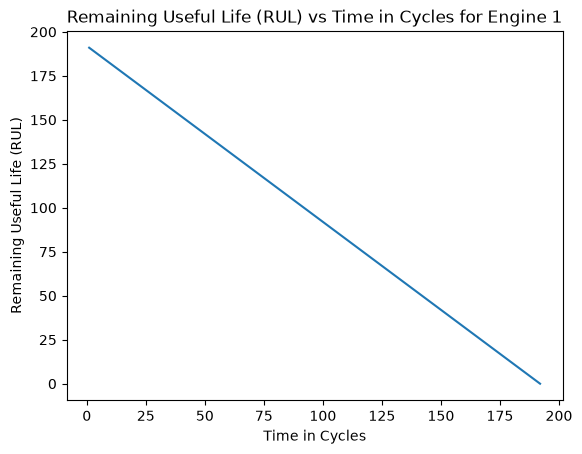

In [32]:
import matplotlib.pyplot as plt

plt.plot(df_merge[df_merge["unit_number"] == 1]["time_in_cycles"], df_merge[df_merge["unit_number"] == 1]["RUL"])
plt.title("Remaining Useful Life (RUL) vs Time in Cycles for Engine 1")
plt.xlabel("Time in Cycles")
plt.ylabel("Remaining Useful Life (RUL)")

# Save the engineered dataset

In [38]:
import os
output_dir = "../data/processed"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df_merge.to_csv(output_dir + "/train_FD001_with_RUL.csv", index=False)

# Rolling Statistics

This section creates rolling averages for important sensors to capture recent engine behavior.

In [49]:
df_merge['sensor_measurement_9_roll_mean_5'] = (
    df_merge.groupby('unit_number')['sensor_measurement_9']
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True))

# Verifying results

In [52]:
engine_1 = df_merge[df_merge['unit_number'] == 1]
engine_1[['time_in_cycles', 'sensor_measurement_9', 'sensor_measurement_9_roll_mean_5']]

,time_in_cycles,sensor_measurement_9,sensor_measurement_9_roll_mean_5
0,1,9046.19,NaN
1,2,9044.07,NaN
2,3,9052.94,NaN
3,4,9049.48,NaN
4,5,9055.15,9049.566
...,...,...,...
187,188,9037.91,9043.722
188,189,9044.55,9043.050
189,190,9040.58,9042.424
190,191,9042.76,9040.702


# Visualizing the difference

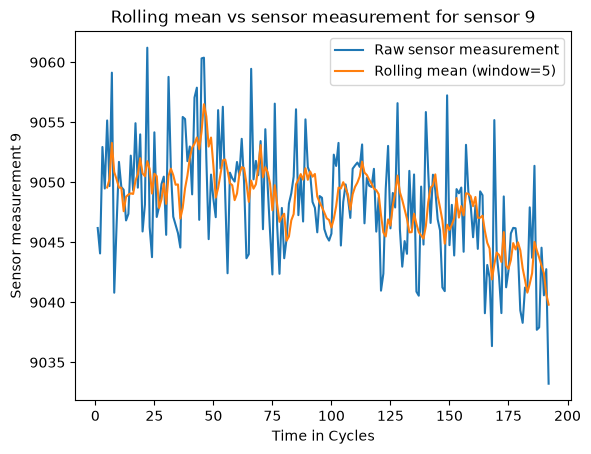

In [59]:
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_measurement_9'], label='Raw sensor measurement')
plt.plot(engine_1['time_in_cycles'], engine_1['sensor_measurement_9_roll_mean_5'], label='Rolling mean (window=5)')
plt.title("Rolling mean vs sensor measurement for sensor 9")
plt.xlabel('Time in Cycles')
plt.ylabel('Sensor measurement 9')
plt.legend()

# Rolling average observations

- The rolling average smooths the data by averaging out the short term noise and fluctuations, revealing the underlying trend in the sensor signal rather than its instantaneous value.
-  The individual, cycle-by-cycle sensor readings were lost; short-term fluctuations and any single cycle spikes are averaged away. This also means the first 4 rows per engine became NaN, since a 5-cycle window has no data to average until the 5th reading.
- The overall degradation trend for each engine became easier to see; instead of a noisy, jagged signal, the rolling mean shows a clearer directional pattern in sensor behavior as the engine ages.
- A model trained on raw sensor values can overfit to sensor noise and single cycle spikes that don't reflect real equipment condition. A rolling mean gives the model a feature that reflects sustained trend rather than momentary noise, which is more likely to generalize and correlate with actual degradation; making it a more reliable signal for predicting RUL.